<a href="https://colab.research.google.com/github/zakiarchivess/ecommerce/blob/2.3/Selamat_Datang_di_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import re

# 1. Load data
df = pd.read_csv('mi_data.csv')

# 2. Membersihkan Harga (Hapus semua karakter non-angka)
df['price_cleaned'] = df['price'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce').fillna(0).astype(int)

# 3. Fungsi Ekstraksi RAM dan Storage
def get_storage(text):
    match = re.search(r'Internal Storage\s*(\d+)', str(text))
    return int(match.group(1)) if match else 0

def get_ram(text):
    match = re.search(r'RAM\s*(\d+)', str(text))
    return int(match.group(1)) if match else 0

df['storage_gb'] = df['storage_ram'].apply(get_storage)
df['ram_gb'] = df['storage_ram'].apply(get_ram)
df['battery_mah'] = df['battery'].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

# 4. FILTER VALIDASI: Menghapus baris yang datanya "Bergeser" (Mismatch)
# Kita bandingkan storage yang ada di 'model_names' dengan 'storage_gb'
def is_data_valid(row):
    # Ambil angka storage dari nama model, misal: "(... 32 GB)" -> 32
    name_storage = re.search(r'(\d+)\s*GB', row['model_names'])
    if name_storage:
        val_in_name = int(name_storage.group(1))
        # Jika beda jauh dengan hasil ekstraksi, berarti data bergeser (error di CSV-nya)
        return val_in_name == row['storage_gb']
    return True

# Terapkan filter untuk membuang data yang rusak/mismatch
df_final = df[df.apply(is_data_valid, axis=1)].copy()

# 5. Menampilkan hasil (Menggunakan cara paling aman di Colab)
print(f"Total data awal: {len(df)}")
print(f"Total data setelah dibersihkan dari mismatch: {len(df_final)}")
print("\n10 Data Teratas yang Sudah Valid:")

# Gunakan head() secara langsung tanpa fungsi display() jika masih error
# Di Colab, menuliskan nama dataframe di baris terakhir otomatis akan menampilkan tabel
df_final[['model_names', 'price_cleaned', 'ram_gb', 'storage_gb', 'battery_mah']].head(10)

Total data awal: 548
Total data setelah dibersihkan dari mismatch: 530

10 Data Teratas yang Sudah Valid:


,model_names,price_cleaned,ram_gb,storage_gb,battery_mah
0,"REDMI 10 Power (Sporty Orange, 128 GB)",13500,8,128,6000
1,"REDMI 10 Power (Power Black, 128 GB)",12840,8,128,6000
2,"Redmi 9A Sport (Metallic Blue, 32 GB)",7520,2,32,5000
3,"Redmi 9A Sport (Coral Green, 32 GB)",8450,3,32,5000
4,"Xiaomi 11Lite NE (Vinyl Black, 128 GB)",21644,6,128,4250
5,"Redmi 10 Prime (Phantom Black, 64 GB)",11990,4,64,6000
6,"Mi 11 Lite (Jazz Blue, 128 GB)",17499,8,128,4250
7,"Mi 11 Lite (Vinyl Black, 128 GB)",17499,8,128,4250
8,"Redmi 9A Sport (Coral Green, 32 GB)",7290,2,32,5000
9,"Redmi 9 (Carbon Black, 64 GB)",10480,4,64,5000


In [24]:
# Melihat ringkasan statistik angka
print(df_final[['price_cleaned', 'ram_gb', 'storage_gb', 'battery_mah']].describe())

# Melihat RAM yang paling populer
print("\nJumlah HP berdasarkan kapasitas RAM:")
print(df_final['ram_gb'].value_counts())

       price_cleaned      ram_gb  storage_gb  battery_mah
count     530.000000  530.000000  530.000000   530.000000
mean    16519.492453    7.445283   96.377358  4593.392453
std      8556.824045   15.920224   60.779382   775.343798
min       799.000000    1.000000    6.000000  2000.000000
25%     10499.000000    4.000000   64.000000  4000.000000
50%     14990.000000    6.000000   64.000000  5000.000000
75%     20999.000000    6.000000  128.000000  5000.000000
max     59999.000000  128.000000  256.000000  6000.000000

Jumlah HP berdasarkan kapasitas RAM:
ram_gb
6      166
4      148
8       86
3       59
2       44
12      10
128      8
1        5
64       4
Name: count, dtype: int64


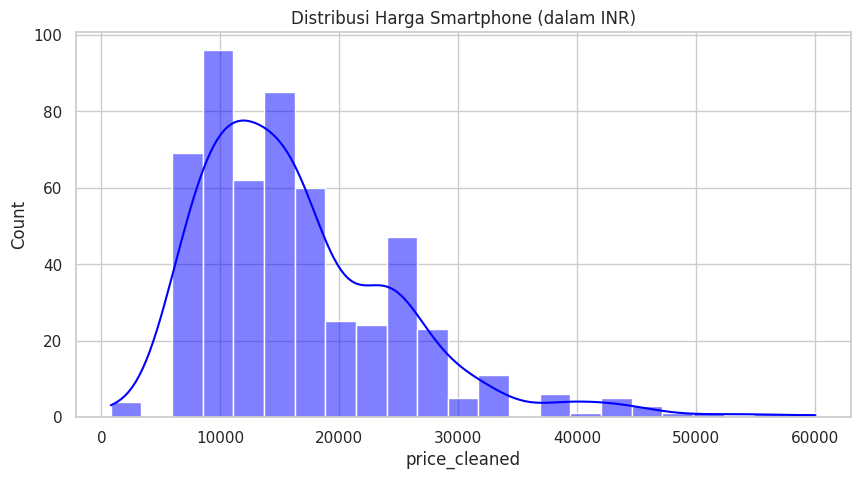

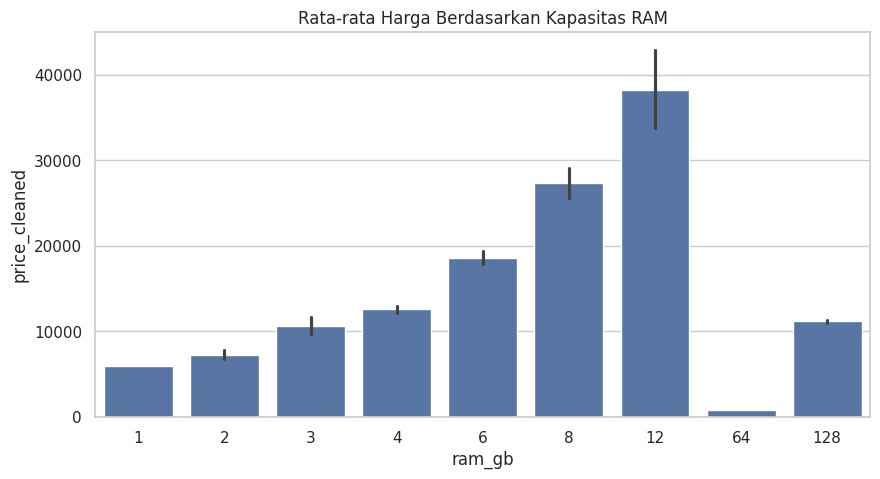

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set tema visualisasi
sns.set(style="whitegrid")

# 1. Histogram Harga
plt.figure(figsize=(10, 5))
sns.histplot(df_final['price_cleaned'], kde=True, color='blue')
plt.title('Distribusi Harga Smartphone (dalam INR)')
plt.show()

# 2. Bar Chart Rata-rata Harga per RAM
plt.figure(figsize=(10, 5))
sns.barplot(x='ram_gb', y='price_cleaned', data=df_final, estimator='mean')
plt.title('Rata-rata Harga Berdasarkan Kapasitas RAM')
plt.show()

In [26]:
# Menentukan kategori kelas HP
def segment_price(price):
    if price < 10000: return 'Entry Level'
    elif price < 20000: return 'Mid Range'
    else: return 'Flagship/High End'

df_final['category'] = df_final['price_cleaned'].apply(segment_price)

# Melihat jumlah HP per kategori
print(df_final['category'].value_counts())

category
Mid Range            269
Flagship/High End    142
Entry Level          119
Name: count, dtype: int64
